In [1]:
from dotenv import load_dotenv
import os 
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import AzureChatOpenAI
from langchain_core.output_parsers import StrOutputParser

load_dotenv('../../env', override=True)
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
if AZURE_OPENAI_API_KEY:
    print(AZURE_OPENAI_API_KEY[:10])
else:
    print("AZURE_OPENAI_API_KEY가 설정되지 않았습니다.")
print(MODEL_NAME)

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_ENDPOINT'] = os.getenv('LANGCHAIN_ENDPOINT')
os.environ['LANGCHAIN_TRACING_V2'] = 'false' #true, false
os.environ['LANGCHAIN_PROJECT'] = 'AGENT'

if os.getenv('LANGCHAIN_TRACING_V2') == "true":
    langsmith_key = os.getenv('LANGSMITH_API_KEY')
    if langsmith_key and len(langsmith_key) > 0:
        print('랭스미스로 추적 중입니다 :', langsmith_key[:10])
    else:
        print('랭스미스 키가 확인되지 않았습니다.')

FuhnkG3b81
gpt-5-nano
랭스미스로 추적 중입니다 : lsv2_pt_ef


In [2]:
import os
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    model=os.environ['MODEL_NAME'],
    azure_deployment=os.environ["MODEL_NAME"],
    azure_endpoint=os.environ["END_POINT"],
    openai_api_version="2025-03-01-preview",
    openai_api_key=os.environ["AZURE_OPENAI_API_KEY"],
)
llm.invoke("안녕!")

AIMessage(content='안녕하세요! 반가워요. 오늘은 무엇을 도와드릴까요?\n\n- 한국어 공부나 발음 교정\n- 글쓰기, 번역, 요약\n- 궁금한 점에 대한 정보 찾기\n- 아이디어 브레인스토밍이나 계획 세우기\n- 코딩/수학 문제 풀이\n- 여행 정보나 생활 팁\n\n원하는 활동이나 주제가 있으면 말씀해 주세요. 한국어로 대화 연습도 같이 할 수 있어요! 무엇부터 시작할까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 827, 'prompt_tokens': 9, 'total_tokens': 836, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 704, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-D72ePmCUW2dM4Ms6Cfd0XuoQLAFaL', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'detected': False, 'filtered': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violenc

1. __API 안정성 및 하위 호환성__       

    그래프 단위(StateGraph 등), 노드(node)/엣지(edge) 모델, 실행(runtime) 모델 등 기존 핵심 구조에 대해 “변경 없음(unchanged)”을 강조.
    따라서 기존 v0.3 버전에서 LangGraph를 사용하던 코드가 “큰 구조 변경 없이” v1.0으로 변경 가능.

1. __신뢰성 및 실행 인프라 강화__      

    내구 실행(durable execution) 기능, 체크포인팅(checkpointing), 지속성(persistence),     
    스트리밍(streaming), 휴먼-인-더-루프(human-in-the-loop) 등의 기능이 “1급 객체(first-class)”으로 유지 강조.

    예컨대 장시간 실행되는 에이전트, 상태 재시작(resume) 가능한 워크플로우 등을 위한 기반이 더욱 견고.

1. __LangChain 생태계와의 통합 강화__      

    LangGraph는 LangChain 에이전트 아키텍처의 기반으로 자리잡았으며,    
    LangChain의 고수준 API (예: create_agent) 가 LangGraph 위에서 실행되는 구조로 변경. 

    즉, LangChain을 통해 빠르게 시작하고(LangChain의 고수준 인터페이스 사용), 필요 시 LangGraph로 “더 낮은 수준의” 제어로 내려가게 설계.

1. __에이전트 일부 기능 폐기 및 이전__     

    create_react_agent라는 함수는 더 이상 권장되지 않고(deprecated), 대신 LangChain의 create_agent를 사용할 것을 권장. 


In [ ]:
from pydantic import BaseModel, Field

class SearchQuery(BaseModel):
    search_query: str = Field(None, description="인터넷 검색에 맞게 최적화된 검색 쿼리")
    justification: str = Field(
        None, description="이 쿼리가 사용자의 요청과 관련이 있는 이유"
    )

structured_llm = llm.with_structured_output(SearchQuery)

output = structured_llm.invoke("여러번 들어도 자꾸 잊어먹어. 어떻게 하면 좋지?")
print(output.search_query)
print(output.justification)

효과적인 기억력 향상 방법
사용자가 여러 번 듣고도 자꾸 잊어먹는 문제를 해결하기 위해 기억력 향상과 관련된 효과적인 방법을 찾고자 하기 때문에 이 검색어가 적합하다.


In [61]:
def multiply(a: int, b: int) -> int:
    """두 수를 곱한다"""
    return a * b

llm_with_tools = llm.bind_tools([multiply])

msg = llm_with_tools.invoke("2랑 3 곱하면 몇이야?")

print(msg)
print(msg.tool_calls)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 58, 'total_tokens': 76, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_3dcd5944f5', 'id': 'chatcmpl-CUoJjijKLUFe1zdhBpaYK5tJ7D6A5', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'tool_calls', 'logprobs': None, 'content_filter_results': {}} id='lc_run--ff8e0944-84af-4b02-9988-d3b9a0a81f35-0' tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_dIbJM

## 조건부 엣지 - conditional edge 

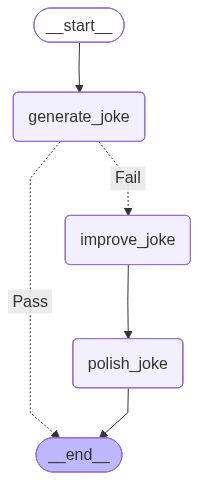

Initial joke:
고양이가 컴퓨터를 쓰다가 왜 화가 났을까요?  
마우스가 안 움직였거든요! 🐱🖱️

--- --- ---



In [69]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

# Invoke
state = chain.invoke({"topic": "고양이"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])

## 함수 api로 작성하기

In [74]:
from langgraph.func import entrypoint, task


@task
def generate_joke(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {topic} in korean")
    return msg.content


def check_punchline(joke: str):
    """Gate function to check if the joke has a punchline"""
    # Simple check - does the joke contain "?" or "!"
    if "?" in joke or "!" in joke:
        return "Fail"

    return "Pass"


@task
def improve_joke(joke: str):
    """Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {joke}")
    return msg.content


@task
def polish_joke(joke: str):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {joke}")
    return msg.content


@entrypoint()
def prompt_chaining_workflow(topic: str):
    original_joke = generate_joke(topic).result()
    if check_punchline(original_joke) == "Pass":
        return original_joke

    improved_joke = improve_joke(original_joke).result()
    return polish_joke(improved_joke).result()
    
# Invoke
for step in prompt_chaining_workflow.stream("고양이", stream_mode="updates"):
    print(step)
    print("\n")

{'generate_joke': '고양이가 컴퓨터 앞에 앉았대요.  \n왜냐고요? ‘마우스’ 잡으러! 😸'}


{'improve_joke': '고양이가 컴퓨터 앞에 앉았대요.  \n왜냐고요? ‘마우스’ 잡으러! 클릭(click) 할 때마다 야옹~! 😸🖱️🐾'}


{'polish_joke': '고양이가 컴퓨터 앞에 앉았대요.  \n왜냐고요? ‘마우스’ 잡으러! 클릭(click) 할 때마다 야옹~! 😸🖱️🐾  \n그런데 갑자기 고양이가 프로그래머가 되더니, 키보드 대신 레이저 포인터로 코딩하기 시작했대요! 🐾💻✨'}


{'prompt_chaining_workflow': '고양이가 컴퓨터 앞에 앉았대요.  \n왜냐고요? ‘마우스’ 잡으러! 클릭(click) 할 때마다 야옹~! 😸🖱️🐾  \n그런데 갑자기 고양이가 프로그래머가 되더니, 키보드 대신 레이저 포인터로 코딩하기 시작했대요! 🐾💻✨'}




### 병렬 및 취합

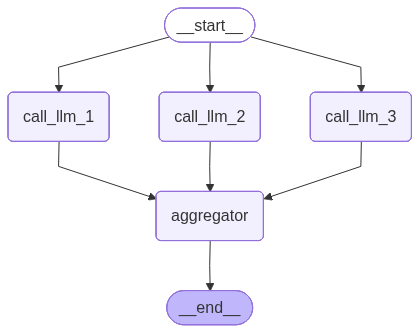

Here's a story, joke, and poem about 고양이!

STORY:
옛날 어느 작은 마을에 고양이 한 마리가 살고 있었습니다. 이름은 미루였고, 부드러운 털과 반짝이는 초록 눈을 가진 미루는 마을 사람들의 사랑을 한 몸에 받았습니다.

미루는 매일 아침 해가 떠오르면 마을을 돌아다니며 사람들을 반겼습니다. 아이들은 미루와 함께 놀며 하루를 시작했고, 어른들은 미루가 지나갈 때면 잠시 손을 멈추고 미소를 지었습니다.

어느 날, 미루는 숲 너머 낯선 소리를 듣게 되었습니다. 호기심에 이끌린 미루는 소리 나는 쪽으로 조심스럽게 발걸음을 옮겼습니다. 그곳에서 작은 새가 다쳐서 날지 못하고 있었습니다.

미루는 새를 조심스럽게 품에 안고 마을로 돌아왔습니다. 사람들은 미루를 도와 새를 치료해주었고, 새는 점차 건강을 되찾았습니다. 마을 사람들은 미루의 용기와 따뜻한 마음에 감동했고, 그 이후로 미루는 더욱 특별한 존재가 되었습니다.

미루는 단순한 고양이가 아니라, 사람과 동물 모두에게 사랑과 희망을 전하는 마을의 작은 영웅이었습니다. 그리고 매일 아침, 미루는 초록 눈을 반짝이며 새로운 하루를 시작했습니다.

JOKE:
왜 고양이는 컴퓨터를 싫어할까?  
마우스가 너무 무서워서! 🐱🖱️

POEM:
고양이, 밤하늘 속 은빛 눈동자  
조용히 걸어가는 그림자 한 조각  
부드러운 숨결에 담긴 비밀의 노래  
살금살금 다가와 마음을 어루만지네

햇살 아래 낮잠에 빠진 행복한 얼굴  
가냘픈 발걸음에도 품은 강인함  
때로는 장난꾸러기, 때로는 현명한 친구  
고요한 집 안에 퍼지는 따스한 온기

고양이여, 자유로운 영혼의 춤사위  
그대와 함께라면 세상도 부드러워지리  
작은 발끝으로 삶을 새로 쓰며  
끝없는 사랑을 가슴에 담아 노래하네


In [75]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "고양이"})
print(state["combined_output"])

### Adaptive Graph

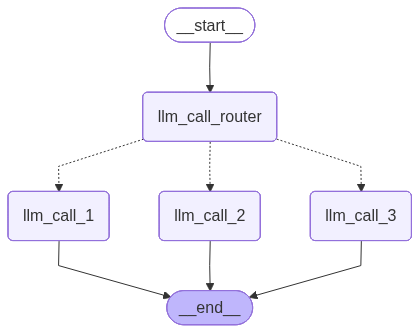

[values] {'input': '고양이에 대한 유머스러운 짧은 시를 써줘'}
[updates] {'llm_call_router': {'decision': 'poem'}}
[values] {'input': '고양이에 대한 유머스러운 짧은 시를 써줘', 'decision': 'poem'}
[updates] {'llm_call_3': {'output': '고양이는 햇볕 속에 쏙,  \n책상 위 점령 작전 쏙쏙.  \n쥐는 어디 갔냐고 물어보면,  \n“내 일은 낮잠, 쥐는 네가 하라옹!”'}}
[values] {'input': '고양이에 대한 유머스러운 짧은 시를 써줘', 'decision': 'poem', 'output': '고양이는 햇볕 속에 쏙,  \n책상 위 점령 작전 쏙쏙.  \n쥐는 어디 갔냐고 물어보면,  \n“내 일은 낮잠, 쥐는 네가 하라옹!”'}
고양이는 햇볕 속에 쏙,  
책상 위 점령 작전 쏙쏙.  
쥐는 어디 갔냐고 물어보면,  
“내 일은 낮잠, 쥐는 네가 하라옹!”


In [ ]:
from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)

# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile(debug=True)

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = router_workflow.invoke({"input": "고양이에 대한 유머스러운 짧은 시를 써줘"})
print(state["output"])